# Question:
main RQ for the utility part: 
- How does categorizing cases into vitalizing process affect process mining utility?

RQ for Quality od discovered model aspect: 
- How does applying lcp and finding vitalizing process affect the quality of the discovered process model?

RQs for complexity and similarity of eventlogs:
- How does applying lcp and finding vitalizing process affect the cimplexity and similarity of eventlogs? 

# Hypothesis:
- The F1 score for the vitalizing process sublog is not decreaing vs random log and whole log
- The log complexity measures in vitalizing process are lower than whole log and random log 
- The similarity measures in vitalizing process are higher than wholelog, random log



# Assumption:
preprocessing  for all logs:
- remove incomplete cases based on end activity: closed, head_ref_deleted in 3 logs
- remove some traces with rare repeptition (I mean 40!) in whole logs and vitalizing log 
- sample random log based on same case size equal to vitalizing log after preprocessing
   

# Inputs:
- one sublog of vitalizing process
- one sublog random as group control group
- one whole log

# Methods and desgin choices:
- create random log
    - by trace or by case?
        - equal case size to vitalizing log

- miner algorithms
    - Alpha miner
        - ALPHA_VERSION_CLASSIC / PLUS
    - Heuristics Miner
        - dependency_threshold 0.5 (default)=
        - and_threshold 0.65 default
        - loop_two_threshold 0.5 default
    - Inductive Miner
        - IM / IMf (noise) 
        - noiseThreshold: 0.0 clean, 0.2 noisy

- evaluation
    - Fitness method
        - Token-based replay
    - Precision method
        - ETC (token-based)
    - F1
        - Harmonic mean


# Outputs:
- compare table of f1 in idfferent miners acrooss 3 log
- compare different configs of parameters
- compare table of discovered model complexity in idfferent miners acrooss 3 log

# Experimental Setup

assessed the quality of the produced models across various quality dimensions:
    - fitness, precision, and F-score as proxies for accuracy
    - generalization, size, control-flow complexity (CFC), and simplicity as proxies for complexity 
     The size metric represents the number of elements in the process model, such as nodes (tasks, events, gateways) and edges, while CFC measures the structural complexity of the control-flow, considering constructs like splits and joins (XOR, AND).


 # Conclusion:





In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pathlib import Path
import pm4py
from pm4py.objects.log.obj import EventLog, Trace, Event

SQLITE_PATH = Path(r"C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\ocel2_commitizen.sqlite")
OBJECT_TYPE = "issue"          # flatten around this object type
TOP_N_VARIANTS = 20            # how many variants to show in the chart
FIGURES_DIR = Path(".")
# Build a flattened event log by joining all event-type subtables for timestamps.
# pm4py 2.7 ocel_flattening only materialises 'user' objects from this schema,
# so we read directly from SQLite and produce a standard pm4py-compatible DataFrame.

SUBTABLES = [
    "event_assigned", "event_closed", "event_commented", "event_committed",
    "event_created", "event_cross_referenced", "event_labeled", "event_merged",
    "event_referenced", "event_renamed", "event_reopened", "event_reviewed",
    "event_review_requested", "event_subscribed", "event_head_ref_deleted",
    "event_head_ref_force_pushed", "event_ready_for_review",
    "event_convert_to_draft", "event_unlabeled", "event_milestoned",
    "event_demilestoned", "event_unassigned", "event_mentioned",
    "event_auto_merge_disabled", "event_auto_rebase_enabled",
    "event_auto_squash_enabled", "event_base_ref_changed",
    "event_base_ref_deleted", "event_base_ref_force_pushed",
    "event_connected", "event_converted_to_discussion",
    "event_copilot_work_finished", "event_copilot_work_started",
    "event_head_ref_restored", "event_issue_type_added",
    "event_issue_type_changed", "event_locked", "event_parent_issue_added",
    "event_pinned", "event_review_request_removed",
    "event_sub_issue_added", "event_unsubscribed", "event_unpinned",
]

CONN = sqlite3.connect(SQLITE_PATH)

union_sql = " UNION ALL ".join(
    f"SELECT ocel_id, ocel_time FROM {t}" for t in SUBTABLES
)
times_df = pd.read_sql(union_sql, CONN)

events_df = pd.read_sql(
    "SELECT e.ocel_id, em.ocel_type_map AS activity, eo.ocel_object_id "
    "FROM event e "
    "JOIN event_map_type em ON e.ocel_type = em.ocel_type "
    "JOIN event_object eo ON e.ocel_id = eo.ocel_event_id",
    CONN,
)
case_ids = pd.read_sql(
    f"SELECT ocel_id FROM object WHERE ocel_type = '{OBJECT_TYPE}'", CONN
)["ocel_id"]

flat = (
    events_df
    .merge(times_df, on="ocel_id", how="left")
    .loc[lambda df: df["ocel_object_id"].isin(case_ids)]
    .dropna(subset=["ocel_time"])
    .rename(columns={"ocel_object_id": "case:concept:name",
                     "activity":       "concept:name",
                     "ocel_time":      "time:timestamp"})
    .sort_values(["case:concept:name", "time:timestamp"])
    .reset_index(drop=True)
)
flat["time:timestamp"] = pd.to_datetime(flat["time:timestamp"], utc=True)
CONN.close()

print(f"Flattened log: {len(flat)} events, {flat['case:concept:name'].nunique()} cases")
print(flat[["case:concept:name", "concept:name", "time:timestamp"]].head(10))

Flattened log: 25893 events, 1709 cases
  case:concept:name           concept:name            time:timestamp
0            100019                created 2020-11-21 14:00:43+00:00
1            100019              commented 2020-11-21 14:03:19+00:00
2            100019               reviewed 2020-11-21 14:07:30+00:00
3            100019  head_ref_force_pushed 2020-11-21 15:17:01+00:00
4            100019              committed 2020-11-21 15:31:42+00:00
5            100019  head_ref_force_pushed 2020-11-21 15:31:50+00:00
6            100019                 merged 2020-11-21 15:40:18+00:00
7            100019                 closed 2020-11-21 15:40:18+00:00
8            100062                created 2020-11-21 13:59:15+00:00
9            100062              commented 2020-11-21 14:01:39+00:00


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
# Load anomaly object IDs
anomaly_df = pd.read_csv("anomaly_object_ids.csv")
anomaly_df["object_id"] = anomaly_df["object_id"].astype(str)

print(f"Anomaly objects: {anomaly_df['object_id'].nunique()} unique, "
      f"{anomaly_df['week_start'].nunique()} anomaly weeks")
anomaly_df.head()

Anomaly objects: 421 unique, 25 anomaly weeks


,week_start,object_id
0,2019-04-15,116370
1,2019-04-15,116396
2,2019-04-15,116442
3,2019-04-15,116518
4,2019-04-15,116547


In [3]:
# Right-join anomaly_df (left) onto flat (right) on object_id / case:concept:name.
# how='right' keeps every row in flat; week_start is populated for anomaly objects, NaN otherwise.
anomaly_events_df = flat[
    flat["case:concept:name"].isin(anomaly_df["object_id"])
].copy()

print(f"Anomaly events df: {len(anomaly_events_df)} rows, "
      f"{anomaly_events_df['case:concept:name'].nunique()} cases")
anomaly_events_df.head()

Anomaly events df: 6831 rows, 421 cases


,ocel_id,concept:name,case:concept:name,time:timestamp
190,100772,created,100768,2020-11-02 14:58:06+00:00
191,100777,labeled,100768,2020-11-02 14:58:06+00:00
192,100780,commented,100768,2020-11-04 11:21:12+00:00
193,100784,commented,100768,2020-11-04 11:32:33+00:00
194,100788,commented,100768,2020-11-11 10:10:59+00:00


In [4]:
import math
import warnings
from typing import Any, Dict, Tuple

import numpy as np
import pandas as pd

from pm4py.objects.log.obj import Event, EventLog, Trace
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter


In [5]:
# -----------------------------
# 1) Reproducibility and config
# -----------------------------
SEED = 40
IMF_NOISE_THRESHOLDS = [0.3, 0.4, 0.5, 0.6]
HEURISTICS_DEP_THRESHOLDS = [0.6, 0.7, 0.8, 0.9]
END_ACTIVITY_1 = "closed"
END_ACTIVITY_2 = "head_ref_deleted"
rng = np.random.default_rng(SEED)

# Required input variables from ocel2_variant_analysis.ipynb
required_globals = ["flat", "anomaly_events_df"]
missing_globals = [g for g in required_globals if g not in globals()]
if missing_globals:
    raise NameError(
        "Missing required variables in memory: "
        f"{missing_globals}. Run ocel2_variant_analysis.ipynb first (cells creating flat and anomaly_events_df)."
    )

flat_df = flat.copy()
vitalizing_df = anomaly_events_df.copy()

In [6]:
# ---------------------------------
# 2) Validate and standardize schema
# ---------------------------------
required_cols = ["case:concept:name", "concept:name", "time:timestamp"]


def validate_and_standardize(df: pd.DataFrame, name: str) -> pd.DataFrame:
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{name} is missing required columns: {missing_cols}")

    out = df[required_cols].copy()
    out["case:concept:name"] = out["case:concept:name"].astype(str)
    out["concept:name"] = out["concept:name"].astype(str)
    out["time:timestamp"] = pd.to_datetime(out["time:timestamp"], utc=True, errors="coerce")

    out = out.dropna(subset=required_cols)
    out = out.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)

    if out.empty:
        raise ValueError(f"{name} is empty after cleaning.")

    return out


flat_df = validate_and_standardize(flat_df, "flat")
vitalizing_df = validate_and_standardize(vitalizing_df, "anomaly_events_df")


In [7]:
# -----------------------------------------
# 3) Preprocess logs and build random control
# -----------------------------------------
def remove_incomplete_traces_two_ends(
    df: pd.DataFrame,
    end_activity_1: str,
    end_activity_2: str,
) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    ordered = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
    last_events = ordered.groupby("case:concept:name", sort=False).tail(1)
    valid_cases = last_events[
        last_events["concept:name"].isin([end_activity_1, end_activity_2])
    ]["case:concept:name"]

    return (
        ordered[ordered["case:concept:name"].isin(valid_cases)]
        .copy()
        .reset_index(drop=True)
    )


flat_df = remove_incomplete_traces_two_ends(flat_df, END_ACTIVITY_1, END_ACTIVITY_2)
vitalizing_df = remove_incomplete_traces_two_ends(vitalizing_df, END_ACTIVITY_1, END_ACTIVITY_2)

if flat_df.empty or vitalizing_df.empty:
    raise ValueError("Preprocessing removed all traces from whole or vitalizing log.")

num_vital_cases = vitalizing_df["case:concept:name"].nunique()
all_cases = flat_df["case:concept:name"].drop_duplicates().to_numpy()

if num_vital_cases > len(all_cases):
    raise ValueError(
        f"Vitalizing cases ({num_vital_cases}) exceed preprocessed whole-log cases ({len(all_cases)})."
    )

sampled_cases = rng.choice(all_cases, size=num_vital_cases, replace=False)
random_case_control_df = (
    flat_df[flat_df["case:concept:name"].isin(sampled_cases)]
    .copy()
    .sort_values(["case:concept:name", "time:timestamp"])
    .reset_index(drop=True)
)

# -------------------------------
# 4) Convert DataFrame -> EventLog
# -------------------------------
def df_to_event_log(df: pd.DataFrame) -> EventLog:
    elog = EventLog()
    for case_id, grp in df.groupby("case:concept:name", sort=False):
        tr = Trace()
        tr.attributes["concept:name"] = str(case_id)
        for _, row in grp.iterrows():
            tr.append(
                Event(
                    {
                        "concept:name": row["concept:name"],
                        "time:timestamp": row["time:timestamp"],
                        "case:concept:name": row["case:concept:name"],
                    }
                )
            )
        elog.append(tr)
    return elog


log_groups_df = {
    "vitalizing": vitalizing_df,
    "whole": flat_df,
    "random_case_control": random_case_control_df,
}

log_groups_eventlog = {name: df_to_event_log(df) for name, df in log_groups_df.items()}

# ---------------------------
# Statistics table (3 event logs)
# ---------------------------
stats_rows = []
for log_group, df in log_groups_df.items():
    n_events = len(df)
    n_cases = df["case:concept:name"].nunique()
    n_activities = df["concept:name"].nunique()
    avg_events_per_case = n_events / n_cases if n_cases else np.nan
    stats_rows.append(
        {
            "log_group": log_group,
            "n_events": n_events,
            "n_cases": n_cases,
            "n_distinct_activities": n_activities,
            "avg_events_per_case": avg_events_per_case,
        }
    )

eventlog_stats_table = pd.DataFrame(stats_rows).sort_values("log_group").reset_index(drop=True)

# ---------------------------
# 5) Model discovery wrappers
# ---------------------------
def discover_alpha(elog: EventLog) -> Tuple[Any, Any, Any]:
    return alpha_miner.apply(elog, variant=alpha_miner.Variants.ALPHA_VERSION_CLASSIC)


def discover_heuristics(elog: EventLog, dep_thresh: float) -> Tuple[Any, Any, Any]:
    params = {
        "dependency_threshold": dep_thresh,
        "and_threshold": 0.65,
        "loop_two_threshold": dep_thresh,
    }
    if hasattr(heuristics_miner, "apply_petri"):
        return heuristics_miner.apply_petri(elog, parameters=params)
    if hasattr(heuristics_miner, "apply"):
        discovered = heuristics_miner.apply(elog, parameters=params)
        if isinstance(discovered, tuple) and len(discovered) == 3:
            return discovered
    raise RuntimeError("Heuristics miner did not return a Petri net in this PM4Py version.")


def discover_inductive(elog: EventLog, variant_name: str = "IM", noise_threshold: float = 0.0) -> Tuple[Any, Any, Any]:
    if variant_name == "IMf":
        try:
            discovered = inductive_miner.apply(
                elog,
                variant=inductive_miner.Variants.IMf,
                parameters={"noise_threshold": noise_threshold},
            )
        except Exception:
            discovered = inductive_miner.apply(
                elog,
                parameters={"noise_threshold": noise_threshold},
            )
    else:
        discovered = inductive_miner.apply(elog)

    # Some PM4Py versions return a ProcessTree for Inductive Miner.
    # Convert ProcessTree -> Petri net tuple expected by evaluation steps.
    if isinstance(discovered, tuple) and len(discovered) == 3:
        return discovered

    net, im, fm = pt_converter.apply(discovered)
    return net, im, fm


def safe_f1(fitness: float, precision: float) -> float:
    if pd.isna(fitness) or pd.isna(precision):
        return np.nan
    if (fitness + precision) == 0:
        return 0.0
    return 2 * fitness * precision / (fitness + precision)


def complexity_size_cfc_simplicity(net: Any) -> Dict[str, float]:
    places = list(getattr(net, "places", []))
    transitions = list(getattr(net, "transitions", []))
    arcs = list(getattr(net, "arcs", []))

    # size: common structural size proxy for Petri nets
    size = float(len(places) + len(transitions) + len(arcs))

    # CFC proxy for Petri nets: sum(max(out_degree(t)-1, 0)) over transitions
    out_counts = {t: 0 for t in transitions}
    for a in arcs:
        src = getattr(a, "source", None)
        if src in out_counts:
            out_counts[src] += 1
    cfc = float(sum(max(v - 1, 0) for v in out_counts.values()))

    # simplicity: best effort from PM4Py simplicity metric, else NaN
    simplicity = np.nan
    try:
        from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

        simplicity = float(simplicity_evaluator.apply(net))
    except Exception:
        pass

    return {"size": size, "cfc": cfc, "simplicity": simplicity}


def compute_generalization(elog: EventLog, net: Any, im: Any, fm: Any) -> float:
    try:
        from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator

        return float(generalization_evaluator.apply(elog, net, im, fm))
    except Exception:
        return np.nan


miners = {
    "alpha_classic": lambda elog: discover_alpha(elog),
    "inductive_IM": lambda elog: discover_inductive(elog, "IM"),
}

for dep_thresh in HEURISTICS_DEP_THRESHOLDS:
    miners[f"heuristics_dep_{dep_thresh:.1f}"] = (
        lambda elog, d=dep_thresh: discover_heuristics(elog, d)
    )

for noise_thr in IMF_NOISE_THRESHOLDS:
    miners[f"inductive_IMf_noise_{noise_thr:.1f}"] = (
        lambda elog, n=noise_thr: discover_inductive(elog, "IMf", n)
    )




# observations:
the presision is very low
current preprocess are not working:
- removing incomplete cases
- swap on thresholds for miner

as follow try to improve the presision in preprocessing:
- diagnose the source of low presision

In [8]:
log  = pm4py.convert_to_event_log(vitalizing_df)
import pm4py
from pm4py.algo.discovery.dfg import algorithm as dfg_alg
from collections import Counter
import numpy as np

variants = pm4py.get_variants(log)

# ── 1. Trace length distribution ──────────────────────────
lengths = [len(trace) for trace in log]
print("=== TRACE LENGTH ===")
print(f"Min:    {min(lengths)}")
print(f"Max:    {max(lengths)}")
print(f"Mean:   {np.mean(lengths):.1f}")
print(f"Median: {np.median(lengths):.1f}")
print(f"Std:    {np.std(lengths):.1f}")

# ── 2. Activity count ──────────────────────────────────────
activity_counts = pm4py.get_event_attribute_values(
    log, "concept:name"
)
print(f"\n=== ACTIVITIES ===")
print(f"Total unique activities: {len(activity_counts)}")
for act, cnt in sorted(activity_counts.items(),
                        key=lambda x: x[1]):
    pct = cnt / len(log) * 100
    print(f"  {act:40s} {cnt:6d}  ({pct:5.1f}%)")

# ── 3. Rework detection ────────────────────────────────────
print("\n=== REWORK (repeated activities per trace) ===")
rework_stats = {}
for trace in log:
    acts = [e["concept:name"] for e in trace]
    counts = Counter(acts)
    for act, cnt in counts.items():
        if cnt > 1:
            rework_stats.setdefault(act, []).append(cnt)

if rework_stats:
    for act, reps in sorted(rework_stats.items(),
                             key=lambda x: len(x[1]),
                             reverse=True):
        pct = len(reps) / len(log) * 100
        print(f"  {act:40s} "
              f"affected: {len(reps):5d} traces ({pct:4.1f}%) "
              f"max reps: {max(reps)}")
else:
    print("  No rework detected")

# ── 4. DFG density ─────────────────────────────────────────
dfg = dfg_alg.apply(log)
n_acts = len(activity_counts)
dfg_density = len(dfg) / (n_acts ** 2)
print(f"\n=== DFG STRUCTURE ===")
print(f"Total DFG arcs:  {len(dfg)}")
print(f"Max possible:    {n_acts ** 2}")
print(f"DFG density:     {dfg_density:.3f}")

# ── 5. Top-10 variant coverage ─────────────────────────────
print("\n=== VARIANT COVERAGE ===")
sorted_v = sorted(variants.items(),
                  key=lambda x: len(x[1]), reverse=True)
cumulative = 0
for i, (v, cases) in enumerate(sorted_v[:10]):
    cumulative += len(cases)
    print(f"  Top-{i+1:2d}: {len(cases):5d} traces | "
          f"cumulative: {cumulative/len(log)*100:.1f}%")

# ── 6. Parallel / concurrent behavior ─────────────────────
print("\n=== CONCURRENCY CHECK ===")
concurrent_pairs = 0
dfg_dict = dict(dfg)
for (a, b) in dfg_dict:
    if (b, a) in dfg_dict:
        concurrent_pairs += 1
print(f"Bidirectional DFG pairs: {concurrent_pairs}")
print(f"  (high number = strong concurrency in process)")

=== TRACE LENGTH ===
Min:    3
Max:    92
Mean:   14.4
Median: 11.0
Std:    11.8

=== ACTIVITIES ===
Total unique activities: 25
  reopened                                      2  (  0.6%)
  issue_type_added                              3  (  1.0%)
  base_ref_deleted                              4  (  1.3%)
  assigned                                      9  (  2.9%)
  milestoned                                   15  (  4.9%)
  convert_to_draft                             19  (  6.1%)
  base_ref_changed                             28  (  9.1%)
  ready_for_review                             35  ( 11.3%)
  base_ref_force_pushed                        44  ( 14.2%)
  renamed                                      53  ( 17.2%)
  unlabeled                                    76  ( 24.6%)
  referenced                                  110  ( 35.6%)
  subscribed                                  132  ( 42.7%)
  mentioned                                   133  ( 43.0%)
  cross_referenced             

In [9]:
import numpy as np
from collections import Counter
import pm4py

vitalizing_log  = pm4py.convert_to_event_log(vitalizing_df)
flat_log  = pm4py.convert_to_event_log(flat_df)

def rework_profile(log):
    """
    For each trace: compute max repetition of any activity.
    Shows how many traces would survive at each threshold.
    """
    max_reps_per_trace = []

    for trace in log:
        acts = [e["concept:name"] for e in trace]
        counts = Counter(acts)
        max_rep = max(counts.values()) if counts else 1
        max_reps_per_trace.append(max_rep)

    max_reps_per_trace = np.array(max_reps_per_trace)

    print(f"{'='*55}")
    print(f"REWORK PROFILE ({len(log)} total traces)")
    print(f"{'='*55}")
    print(f"Traces with NO rework (max_rep=1): "
          f"{(max_reps_per_trace == 1).sum()} "
          f"({(max_reps_per_trace == 1).mean()*100:.1f}%)")
    print()
    print(f"Threshold | Kept traces | % kept | Removed")
    print(f"-" * 50)
    for thresh in [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20]:
        kept = (max_reps_per_trace <= thresh).sum()
        pct  = kept / len(log) * 100
        removed = len(log) - kept
        print(f"  max ≤ {thresh:2d}  | {kept:6d}      | "
              f"{pct:5.1f}% | {removed:6d}")
    print(f"{'='*55}")

    return max_reps_per_trace

rework_dist = rework_profile(vitalizing_log)
rework_dist = rework_profile(flat_log)

REWORK PROFILE (309 total traces)
Traces with NO rework (max_rep=1): 58 (18.8%)

Threshold | Kept traces | % kept | Removed
--------------------------------------------------
  max ≤  1  |     58      |  18.8% |    251
  max ≤  2  |    126      |  40.8% |    183
  max ≤  3  |    197      |  63.8% |    112
  max ≤  4  |    229      |  74.1% |     80
  max ≤  5  |    246      |  79.6% |     63
  max ≤  6  |    264      |  85.4% |     45
  max ≤  7  |    269      |  87.1% |     40
  max ≤  8  |    276      |  89.3% |     33
  max ≤ 10  |    286      |  92.6% |     23
  max ≤ 15  |    294      |  95.1% |     15
  max ≤ 20  |    303      |  98.1% |      6
REWORK PROFILE (1302 total traces)
Traces with NO rework (max_rep=1): 182 (14.0%)

Threshold | Kept traces | % kept | Removed
--------------------------------------------------
  max ≤  1  |    182      |  14.0% |   1120
  max ≤  2  |    407      |  31.3% |    895
  max ≤  3  |    905      |  69.5% |    397
  max ≤  4  |   1037      |  79.

In [10]:
# -----------------------------------------
# Repetition cleaning + results on clean logs
# -----------------------------------------
MAX_REP = 5


def remove_traces_with_high_activity_repetition(
    df: pd.DataFrame,
    max_rep: int = MAX_REP,
) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    ordered = df.sort_values(["case:concept:name", "time:timestamp"]).copy()
    valid_cases = []

    for case_id, grp in ordered.groupby("case:concept:name", sort=False):
        activity_counts = grp["concept:name"].value_counts()
        if activity_counts.max() <= max_rep:
            valid_cases.append(case_id)

    return (
        ordered[ordered["case:concept:name"].isin(valid_cases)]
        .copy()
        .reset_index(drop=True)
    )


vitalizing_df_clean = remove_traces_with_high_activity_repetition(vitalizing_df, MAX_REP)
flat_df_clean = remove_traces_with_high_activity_repetition(flat_df, MAX_REP)

if vitalizing_df_clean.empty or flat_df_clean.empty:
    raise ValueError("Repetition cleaning removed all traces from vitalizing or whole log.")

num_vital_cases_clean = vitalizing_df_clean["case:concept:name"].nunique()
all_cases_clean = flat_df_clean["case:concept:name"].drop_duplicates().to_numpy()

if num_vital_cases_clean > len(all_cases_clean):
    raise ValueError(
        f"Clean vitalizing cases ({num_vital_cases_clean}) exceed clean whole-log cases ({len(all_cases_clean)})."
    )

sampled_cases_clean = rng.choice(all_cases_clean, size=num_vital_cases_clean, replace=False)
random_case_control_df_clean = (
    flat_df_clean[flat_df_clean["case:concept:name"].isin(sampled_cases_clean)]
    .copy()
    .sort_values(["case:concept:name", "time:timestamp"])
    .reset_index(drop=True)
)

print("=== Repetition cleaning summary (MAX_REP = 5) ===")
print(
    f"Vitalizing: {vitalizing_df['case:concept:name'].nunique()} -> "
    f"{vitalizing_df_clean['case:concept:name'].nunique()} cases | "
    f"{len(vitalizing_df)} -> {len(vitalizing_df_clean)} events"
)
print(
    f"Whole: {flat_df['case:concept:name'].nunique()} -> "
    f"{flat_df_clean['case:concept:name'].nunique()} cases | "
    f"{len(flat_df)} -> {len(flat_df_clean)} events"
)
print(
    f"Random control (rebuilt): {random_case_control_df_clean['case:concept:name'].nunique()} cases | "
    f"{len(random_case_control_df_clean)} events"
)

clean_log_groups_df = {
    "vitalizing": vitalizing_df_clean,
    "whole": flat_df_clean,
    "random_case_control": random_case_control_df_clean,
}

clean_log_groups_eventlog = {
    name: df_to_event_log(df) for name, df in clean_log_groups_df.items()
}

clean_records = []
for group_name, elog in clean_log_groups_eventlog.items():
    distinct_traces = len({tuple(ev["concept:name"] for ev in tr) for tr in elog})

    for miner_name, miner_fn in miners.items():
        rec = {
            "log_name": group_name,
            "discovery_method": miner_name,
            "distinct_traces": distinct_traces,
            "generalization": np.nan,
            "fitness": np.nan,
            "precision": np.nan,
            "f_score": np.nan,
            "size": np.nan,
            "cfc": np.nan,
            "simplicity": np.nan,
            "status": "ok",
            "error": None,
        }
        try:
            net, im, fm = miner_fn(elog)

            fit_res = replay_fitness_evaluator.apply(
                elog,
                net,
                im,
                fm,
                variant=replay_fitness_evaluator.Variants.TOKEN_BASED,
            )
            fitness = fit_res.get("log_fitness", np.nan)

            precision = precision_evaluator.apply(
                elog,
                net,
                im,
                fm,
                variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN,
            )

            rec["fitness"] = fitness
            rec["precision"] = precision
            rec["f_score"] = safe_f1(fitness, precision)
            rec["generalization"] = compute_generalization(elog, net, im, fm)
            rec.update(complexity_size_cfc_simplicity(net))

        except Exception as exc:
            rec["status"] = "failed"
            rec["error"] = str(exc)

        clean_records.append(rec)

results_df_clean = pd.DataFrame.from_records(clean_records)

consolidated_results_table_clean = (
    results_df_clean[
        [
            "log_name",
            "discovery_method",
            "distinct_traces",
            "generalization",
            "fitness",
            "precision",
            "f_score",
            "size",
            "cfc",
            "simplicity",
            "status",
            "error",
        ]
    ]
    .sort_values(["discovery_method", "log_name"])
    .reset_index(drop=True)
)

print(
    f"\nSanity: vitalizing cases = {vitalizing_df_clean['case:concept:name'].nunique()} | "
    f"random control cases = {random_case_control_df_clean['case:concept:name'].nunique()}"
)
print(f"Expected records: {len(clean_log_groups_eventlog) * len(miners)} | Observed: {len(results_df_clean)}")

print("\n7) Consolidated results table in clean logs")
display(consolidated_results_table_clean)
consolidated_results_table_clean.to_csv("consolidated_results_table_clean.csv", index=False)

failed_rows_clean = consolidated_results_table_clean[
    consolidated_results_table_clean["status"] == "failed"
][["log_name", "discovery_method", "error"]]
if not failed_rows_clean.empty:
    print("\nSome miner/log combinations failed on clean logs:")
    display(failed_rows_clean)


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 309 -> 246 cases | 4440 -> 2621 events
Whole: 1302 -> 1097 cases | 17821 -> 11838 events
Random control (rebuilt): 246 cases | 2575 events


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 183/183 [00:00<00:00, 395.42it/s]


Sanity: vitalizing cases = 246 | random control cases = 246
Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs


,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,183,0.619610,0.759619,0.124131,0.213391,81.0,8.0,1.000000,ok,None
1,vitalizing,alpha_classic,200,0.767330,0.682766,0.221668,0.334678,105.0,20.0,0.530864,ok,None
2,whole,alpha_classic,668,0.631486,0.622103,0.121225,0.202910,92.0,10.0,1.000000,ok,None
3,random_case_control,heuristics_dep_0.6,183,0.516335,0.836303,0.361193,0.504497,552.0,38.0,0.452991,ok,None
4,vitalizing,heuristics_dep_0.6,200,0.499576,0.793609,0.651619,0.715639,659.0,50.0,0.444248,ok,None
5,whole,heuristics_dep_0.6,668,0.516354,0.849138,0.395904,0.540025,1002.0,69.0,0.426621,ok,None
6,random_case_control,heuristics_dep_0.7,183,0.508988,0.841715,0.350545,0.494958,552.0,38.0,0.452991,ok,None
7,vitalizing,heuristics_dep_0.7,200,0.499588,0.797116,0.649706,0.715902,659.0,50.0,0.444248,ok,None
8,whole,heuristics_dep_0.7,668,0.507550,0.845887,0.409170,0.551547,1002.0,69.0,0.426621,ok,None
9,random_case_control,heuristics_dep_0.8,183,0.514779,0.841715,0.350545,0.494958,552.0,38.0,0.452991,ok,None


## Observations:
- higher f1 for vitiliaxing log
- very low presision in most of the scenarios
- complexity and size are horrible
- insensetive to heuristics_dep threshold! it seems odd!


Plotting from 30 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'heuristics_dep_0.8', 'heuristics_dep_0.9', 'inductive_IM', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'inductive_IMf_noise_0.5', 'inductive_IMf_noise_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved clean_log_f_score_grouped_bars.png


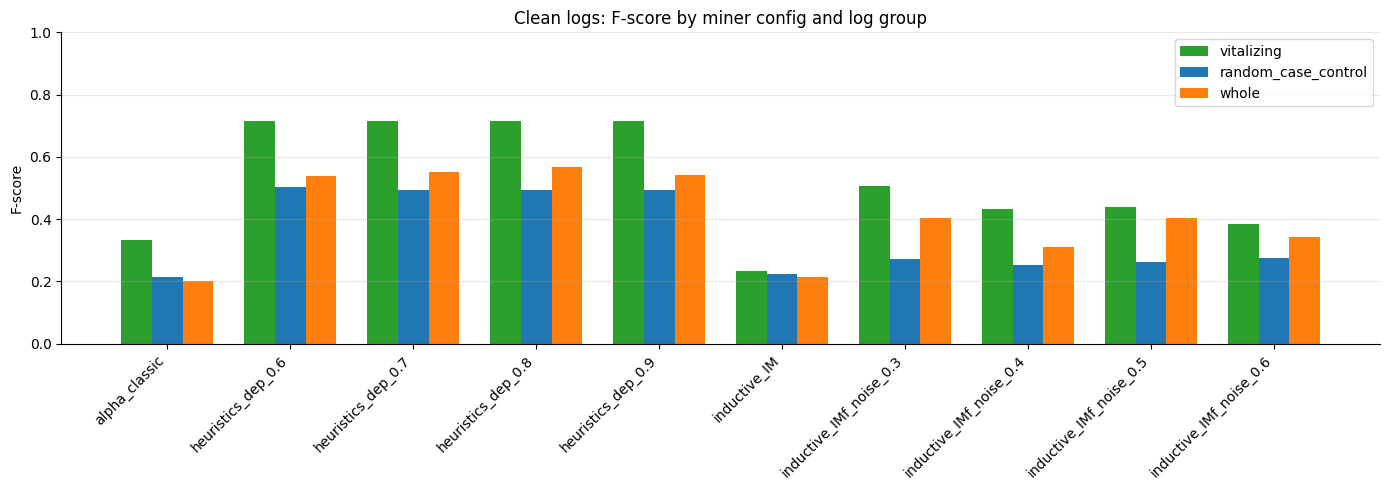

Saved clean_log_fitness_precision.png


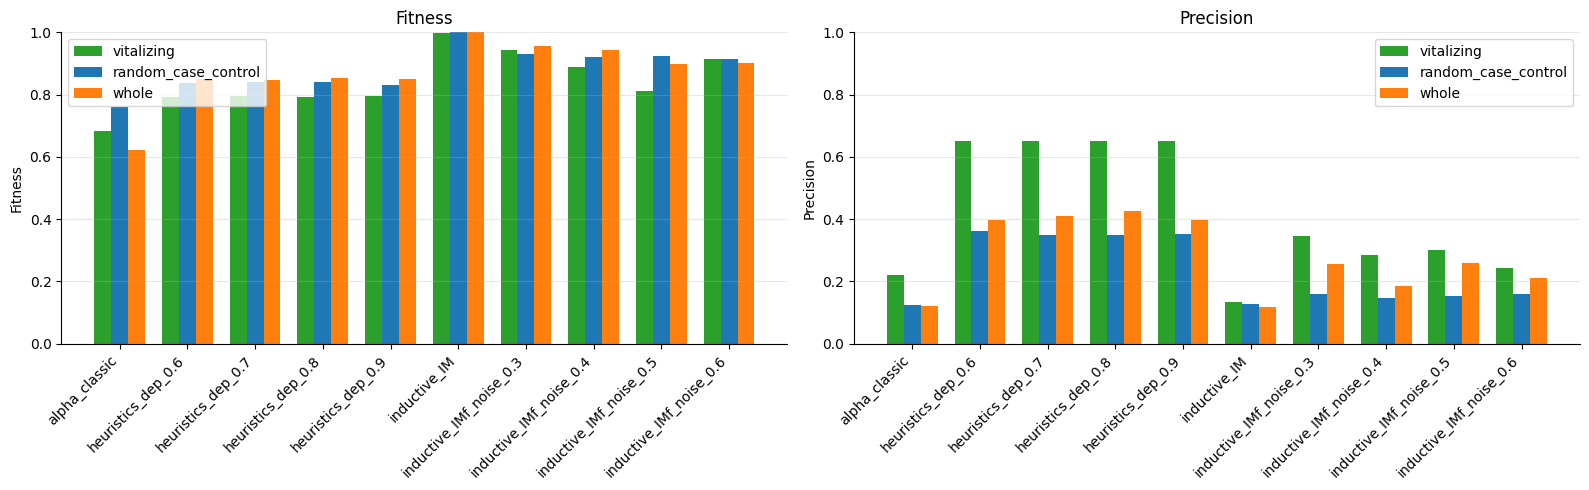

Saved clean_log_complexity.png


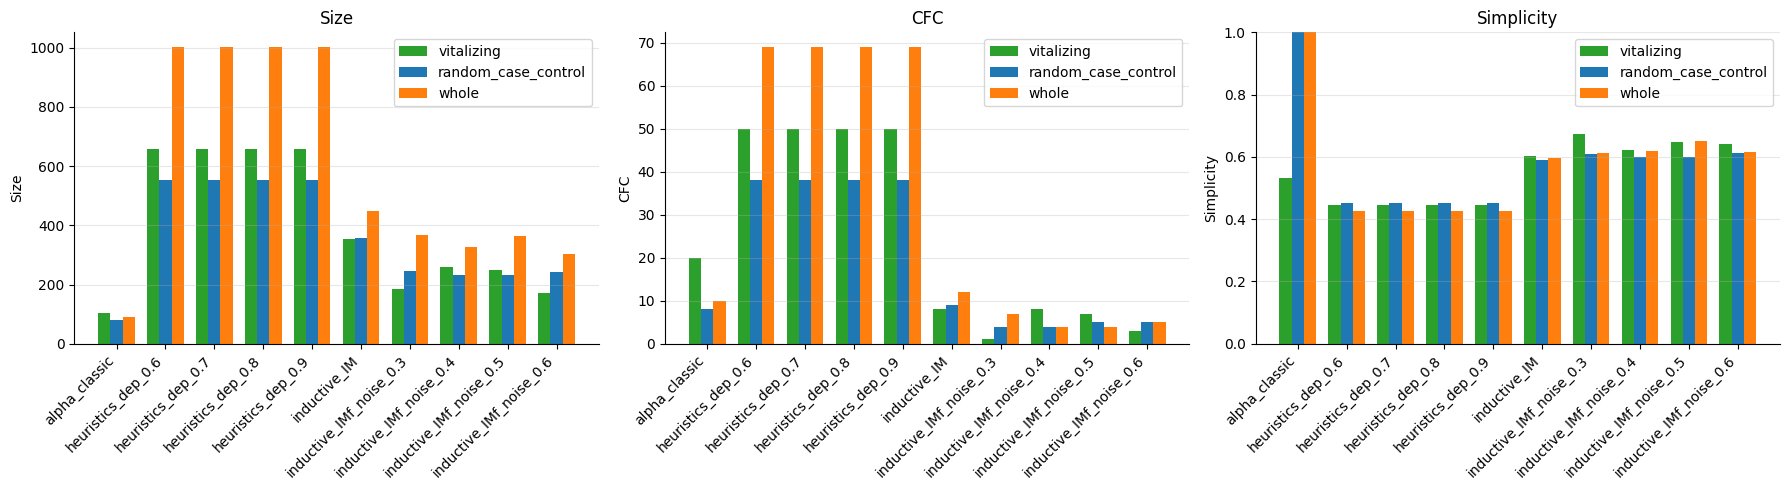

Saved clean_log_threshold_sensitivity.png


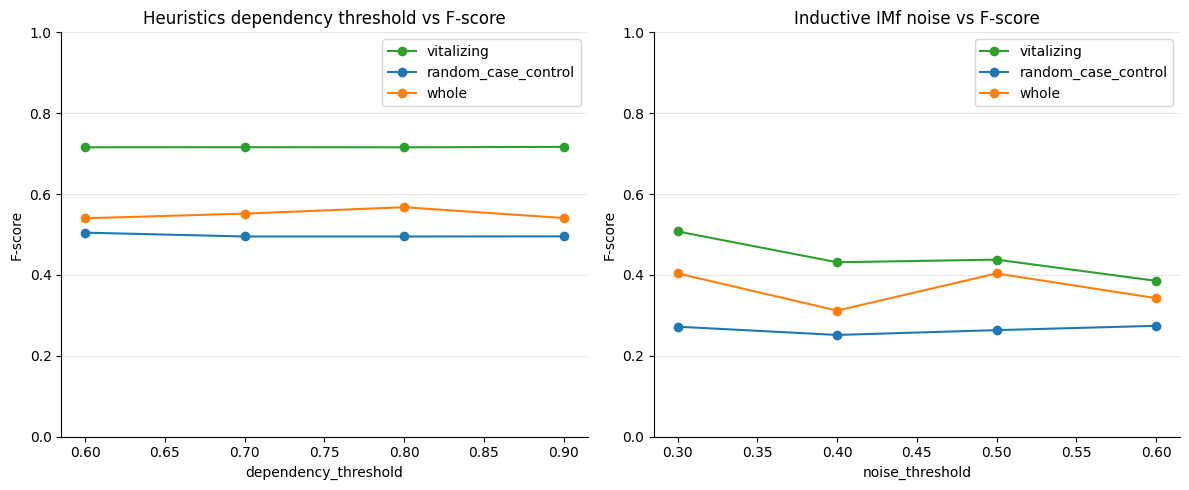

Saved clean_log_f_score_slopegraph.png


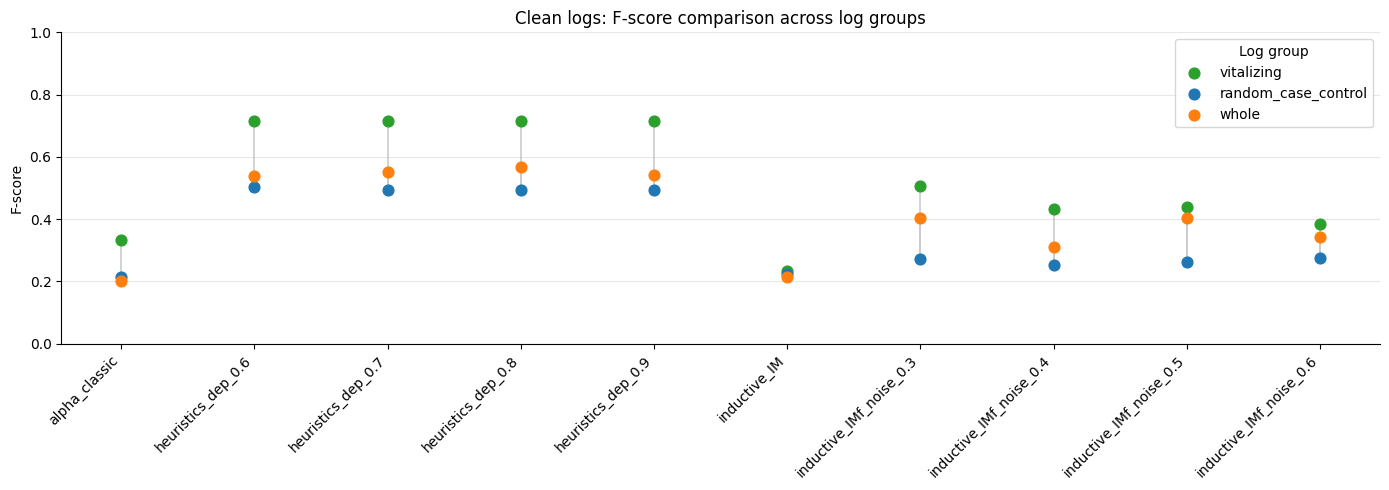

In [12]:
# -----------------------------------------
# Clean-log comparison figures
# -----------------------------------------
LOG_ORDER = ["vitalizing", "random_case_control", "whole"]
LOG_COLORS = {
    "vitalizing": "#2ca02c",
    "random_case_control": "#1f77b4",
    "whole": "#ff7f0e",
}

plot_df = consolidated_results_table_clean[
    consolidated_results_table_clean["status"] == "ok"
].copy()

if plot_df.empty:
    raise ValueError("No successful rows in consolidated_results_table_clean to plot.")

wide_f_score_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="f_score")
    .sort_index(axis=1)
)
wide_fitness_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="fitness")
    .sort_index(axis=1)
)
wide_precision_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="precision")
    .sort_index(axis=1)
)
wide_generalization_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="generalization")
    .sort_index(axis=1)
)
wide_size_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="size")
    .sort_index(axis=1)
)
wide_cfc_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="cfc")
    .sort_index(axis=1)
)
wide_simplicity_clean = (
    plot_df.pivot(index="log_name", columns="discovery_method", values="simplicity")
    .sort_index(axis=1)
)

print(f"Plotting from {len(plot_df)} successful rows")
print(f"Miner configs: {list(wide_f_score_clean.columns)}")
print(f"Log groups: {list(wide_f_score_clean.index)}")


def _style_axes(ax, ylim01=False):
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    if ylim01:
        ax.set_ylim(0, 1)


def plot_grouped_bars(wide_df, title, ylabel, ax, ylim01=False):
    wide_df = wide_df.reindex(LOG_ORDER).dropna(how="all")
    configs = list(wide_df.columns)
    x = np.arange(len(configs))
    width = 0.25

    for i, log_name in enumerate(LOG_ORDER):
        if log_name not in wide_df.index:
            continue
        values = wide_df.loc[log_name, configs].astype(float).values
        offset = (i - (len(LOG_ORDER) - 1) / 2) * width
        ax.bar(
            x + offset,
            values,
            width,
            label=log_name,
            color=LOG_COLORS.get(log_name),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    _style_axes(ax, ylim01=ylim01)


# Figure 1: F-score grouped bars
fig, ax = plt.subplots(figsize=(14, 5))
plot_grouped_bars(
    wide_f_score_clean,
    "Clean logs: F-score by miner config and log group",
    "F-score",
    ax,
    ylim01=True,
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clean_log_f_score_grouped_bars.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "clean_log_f_score_grouped_bars.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURES_DIR / 'clean_log_f_score_grouped_bars'}.{{png,pdf}}")
plt.show()

# Figure 2: Fitness vs Precision
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_grouped_bars(wide_fitness_clean, "Fitness", "Fitness", axes[0], ylim01=True)
plot_grouped_bars(wide_precision_clean, "Precision", "Precision", axes[1], ylim01=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clean_log_fitness_precision.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "clean_log_fitness_precision.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURES_DIR / 'clean_log_fitness_precision'}.{{png,pdf}}")
plt.show()

# Figure 3: Complexity (size, cfc, simplicity)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_grouped_bars(wide_size_clean, "Size", "Size", axes[0])
plot_grouped_bars(wide_cfc_clean, "CFC", "CFC", axes[1])
plot_grouped_bars(wide_simplicity_clean, "Simplicity", "Simplicity", axes[2], ylim01=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clean_log_complexity.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "clean_log_complexity.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURES_DIR / 'clean_log_complexity'}.{{png,pdf}}")
plt.show()

# Figure 4: Threshold sensitivity lines
heur_cols = [c for c in wide_f_score_clean.columns if c.startswith("heuristics_dep_")]
imf_cols = [c for c in wide_f_score_clean.columns if c.startswith("inductive_IMf_noise_")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for log_name in LOG_ORDER:
    if log_name not in wide_f_score_clean.index:
        continue

    heur_pairs = sorted(
        (float(c.replace("heuristics_dep_", "")), c) for c in heur_cols
    )
    heur_x = [p[0] for p in heur_pairs]
    heur_y = [wide_f_score_clean.loc[log_name, p[1]] for p in heur_pairs]
    axes[0].plot(heur_x, heur_y, marker="o", label=log_name, color=LOG_COLORS.get(log_name))

    imf_pairs = sorted(
        (float(c.replace("inductive_IMf_noise_", "")), c) for c in imf_cols
    )
    imf_x = [p[0] for p in imf_pairs]
    imf_y = [wide_f_score_clean.loc[log_name, p[1]] for p in imf_pairs]
    axes[1].plot(imf_x, imf_y, marker="o", label=log_name, color=LOG_COLORS.get(log_name))

axes[0].set_title("Heuristics dependency threshold vs F-score")
axes[0].set_xlabel("dependency_threshold")
axes[0].set_ylabel("F-score")
axes[0].legend()
_style_axes(axes[0], ylim01=True)

axes[1].set_title("Inductive IMf noise vs F-score")
axes[1].set_xlabel("noise_threshold")
axes[1].set_ylabel("F-score")
axes[1].legend()
_style_axes(axes[1], ylim01=True)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "clean_log_threshold_sensitivity.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "clean_log_threshold_sensitivity.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURES_DIR / 'clean_log_threshold_sensitivity'}.{{png,pdf}}")
plt.show()

# Figure 5: F-score slopegraph
slope_data = wide_f_score_clean.reindex(LOG_ORDER)
configs = list(slope_data.columns)
x = np.arange(len(configs))

fig, ax = plt.subplots(figsize=(14, 5))
for cfg_idx in range(len(configs)):
    y_vals = slope_data.iloc[:, cfg_idx].astype(float).values
    ax.plot(
        [cfg_idx] * len(LOG_ORDER),
        y_vals,
        color="#cccccc",
        linewidth=1.2,
        zorder=1,
    )
    for log_idx, log_name in enumerate(LOG_ORDER):
        if log_name not in slope_data.index:
            continue
        ax.scatter(
            cfg_idx,
            slope_data.loc[log_name, configs[cfg_idx]],
            color=LOG_COLORS.get(log_name),
            s=60,
            zorder=2,
            label=log_name if cfg_idx == 0 else None,
        )

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha="right")
ax.set_ylabel("F-score")
ax.set_title("Clean logs: F-score comparison across log groups")
ax.legend(title="Log group")
_style_axes(ax, ylim01=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clean_log_f_score_slopegraph.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "clean_log_f_score_slopegraph.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURES_DIR / 'clean_log_f_score_slopegraph'}.{{png,pdf}}")
plt.show()




In [13]:
# -----------------------------------------
# Log complexity + within-log similarity (process-complexity / EPA toolkit)
# -----------------------------------------
import importlib
import subprocess
import sys

# Auxiliary deps required by the toolkit. pm4py is intentionally NOT installed
# from its requirements.txt to avoid downgrading the version used above.
for _pkg, _mod in [("BitVector", "BitVector"), ("lempel_ziv_complexity", "lempel_ziv_complexity")]:
    try:
        importlib.import_module(_mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])

COMPLEXITY_REPO = Path("process-complexity").resolve()
if str(COMPLEXITY_REPO) not in sys.path:
    sys.path.insert(0, str(COMPLEXITY_REPO))
import Complexity


def _variant_case_counts(elog):
    variants = pm4py.get_variants(elog)
    counts = [len(v) if hasattr(v, "__len__") else int(v) for v in variants.values()]
    return np.array(sorted(counts, reverse=True), dtype=float)


def _gini(counts):
    if counts.size == 0 or counts.sum() == 0:
        return np.nan
    x = np.sort(counts)
    n = x.size
    total = x.sum()
    # Gini via the order-weighted formulation
    return float((2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * total) / (n * total))


rows = []
for name in LOG_ORDER:
    pm_log = clean_log_groups_eventlog[name]
    row = {"log_name": name}
    try:
        plain = Complexity.generate_log(pm_log)
        pa = Complexity.build_graph(plain)

        var_ent, var_ent_norm = Complexity.graph_complexity(pa)
        seq_ent, seq_ent_norm = Complexity.log_complexity(pa)
        row.update(
            {
                "variant_entropy": var_ent,
                "norm_variant_entropy": var_ent_norm,
                "sequence_entropy": seq_ent,
                "norm_sequence_entropy": seq_ent_norm,
            }
        )

        measures = Complexity.perform_measurements(
            ["all"], log=plain, pm4py_log=pm_log, pa=pa, quiet=True
        )
        for key, value in measures.items():
            if isinstance(value, dict):
                for sub_key, sub_val in value.items():
                    row[f"{key} ({sub_key})"] = sub_val
            else:
                row[key] = value
    except Exception as exc:
        row["error"] = str(exc)
        print(f"[{name}] complexity computation failed: {exc}")

    # Supplementary within-log similarity / concentration stats
    try:
        counts = _variant_case_counts(pm_log)
        total = counts.sum()
        row["top1_variant_coverage"] = float(counts[0] / total) if counts.size else np.nan
        row["top10_variant_coverage"] = float(counts[:10].sum() / total) if counts.size else np.nan
        row["gini_variant_concentration"] = _gini(counts)
    except Exception as exc:
        print(f"[{name}] similarity stats failed: {exc}")

    rows.append(row)

log_complexity_similarity_table = (
    pd.DataFrame(rows).set_index("log_name").reindex(LOG_ORDER)
)

print("Log complexity + within-log similarity metrics:")
display(log_complexity_similarity_table)
log_complexity_similarity_table.to_csv("log_complexity_similarity_metrics.csv")
print("Saved log_complexity_similarity_metrics.csv")

Log complexity + within-log similarity metrics:


,variant_entropy,norm_variant_entropy,sequence_entropy,norm_sequence_entropy,Magnitude,Support,Variety,Level of detail,Time granularity,Structure,...,Trace length (avg),Trace length (max),Distinct traces,Deviation from random,Lempel-Ziv complexity,Pentland's task complexity,Pentland's process complexity,top1_variant_coverage,top10_variant_coverage,gini_variant_concentration
log_name,,,,,,,,,,,,,,,,,,,,,
vitalizing,7663.992365,0.693386,12269.628167,0.594727,2621,246,25,7.711382,45.398374,0.675200,...,10.654472,31,81.300813,0.846721,760,2277,2.089296e+14,0.028455,0.166667,0.171626
random_case_control,6269.737302,0.702747,11705.817340,0.578836,2575,246,31,7.735772,58.073171,0.800208,...,10.467480,30,74.390244,0.816662,696,1960,9.120108e+12,0.052846,0.211382,0.233951
whole,28822.880326,0.745845,62885.128660,0.566383,11838,1097,40,7.868733,50.658159,0.793750,...,10.791249,31,60.893345,0.820775,2662,7852,1.905461e+23,0.058341,0.198724,0.368197


Saved log_complexity_similarity_metrics.csv


In [15]:
# -----------------------------------------
# Random-sample reproducibility across seeds
# -----------------------------------------
# Redraw the clean random-control sample under multiple seeds and recompute both
# the process-discovery metrics and the EPA complexity / within-log similarity
# metrics. A per-seed local RNG is used so the global `rng` and the existing
# `random_case_control_df_clean` are left untouched.
REPRO_SEEDS = list(range(10))

repro_discovery_rows = []
repro_complexity_rows = []

for seed in REPRO_SEEDS:
    local_rng = np.random.default_rng(seed)
    sampled = local_rng.choice(all_cases_clean, size=num_vital_cases_clean, replace=False)
    sample_df = (
        flat_df_clean[flat_df_clean["case:concept:name"].isin(sampled)]
        .copy()
        .sort_values(["case:concept:name", "time:timestamp"])
        .reset_index(drop=True)
    )
    elog = df_to_event_log(sample_df)

    # --- (a) process-discovery metrics (mirrors the clean-log results cell) ---
    for miner_name, miner_fn in miners.items():
        rec = {
            "seed": seed,
            "discovery_method": miner_name,
            "fitness": np.nan,
            "precision": np.nan,
            "f_score": np.nan,
            "generalization": np.nan,
            "size": np.nan,
            "cfc": np.nan,
            "simplicity": np.nan,
            "status": "ok",
            "error": None,
        }
        try:
            net, im, fm = miner_fn(elog)

            fit_res = replay_fitness_evaluator.apply(
                elog,
                net,
                im,
                fm,
                variant=replay_fitness_evaluator.Variants.TOKEN_BASED,
            )
            fitness = fit_res.get("log_fitness", np.nan)

            precision = precision_evaluator.apply(
                elog,
                net,
                im,
                fm,
                variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN,
            )

            rec["fitness"] = fitness
            rec["precision"] = precision
            rec["f_score"] = safe_f1(fitness, precision)
            rec["generalization"] = compute_generalization(elog, net, im, fm)
            rec.update(complexity_size_cfc_simplicity(net))
        except Exception as exc:
            rec["status"] = "failed"
            rec["error"] = str(exc)

        repro_discovery_rows.append(rec)

    # --- (b) EPA complexity + within-log similarity metrics ---
    crow = {"seed": seed}
    try:
        plain = Complexity.generate_log(elog)
        pa = Complexity.build_graph(plain)

        var_ent, var_ent_norm = Complexity.graph_complexity(pa)
        seq_ent, seq_ent_norm = Complexity.log_complexity(pa)
        crow.update(
            {
                "variant_entropy": var_ent,
                "norm_variant_entropy": var_ent_norm,
                "sequence_entropy": seq_ent,
                "norm_sequence_entropy": seq_ent_norm,
            }
        )

        measures = Complexity.perform_measurements(
            ["all"], log=plain, pm4py_log=elog, pa=pa, quiet=True
        )
        for key, value in measures.items():
            if isinstance(value, dict):
                for sub_key, sub_val in value.items():
                    crow[f"{key} ({sub_key})"] = sub_val
            else:
                crow[key] = value
    except Exception as exc:
        crow["error"] = str(exc)
        print(f"[seed={seed}] complexity computation failed: {exc}")

    try:
        counts = _variant_case_counts(elog)
        total = counts.sum()
        crow["top1_variant_coverage"] = float(counts[0] / total) if counts.size else np.nan
        crow["top10_variant_coverage"] = float(counts[:10].sum() / total) if counts.size else np.nan
        crow["gini_variant_concentration"] = _gini(counts)
    except Exception as exc:
        print(f"[seed={seed}] similarity stats failed: {exc}")

    repro_complexity_rows.append(crow)

repro_discovery_df = pd.DataFrame(repro_discovery_rows)
repro_complexity_df = pd.DataFrame(repro_complexity_rows).set_index("seed")

repro_discovery_df.to_csv("repro_discovery_metrics.csv", index=False)
repro_complexity_df.to_csv("repro_complexity_similarity_metrics.csv")


def _cv(series):
    m = series.mean()
    return series.std(ddof=1) / abs(m) if m not in (0, np.nan) and not pd.isna(m) and m != 0 else np.nan


# Discovery reproducibility summary: mean/std/CV per miner across seeds
_disc_ok = repro_discovery_df[repro_discovery_df["status"] == "ok"]
_disc_metrics = ["fitness", "precision", "f_score", "size", "cfc"]
repro_discovery_summary = _disc_ok.groupby("discovery_method")[_disc_metrics].agg(
    ["mean", "std", _cv]
)
repro_discovery_summary.columns = [
    f"{metric}_{'cv' if stat == '_cv' else stat}" for metric, stat in repro_discovery_summary.columns
]
repro_discovery_summary = repro_discovery_summary.reset_index()

# Complexity/similarity reproducibility summary: mean/std/CV per metric across seeds
_num_cols = repro_complexity_df.select_dtypes("number").columns
repro_complexity_summary = pd.DataFrame(
    {
        "mean": repro_complexity_df[_num_cols].mean(),
        "std": repro_complexity_df[_num_cols].std(ddof=1),
    }
)
repro_complexity_summary["cv"] = (
    repro_complexity_summary["std"] / repro_complexity_summary["mean"].abs()
)
repro_complexity_summary = repro_complexity_summary.sort_values("cv")

repro_discovery_summary.to_csv("repro_discovery_summary.csv", index=False)
repro_complexity_summary.to_csv("repro_complexity_summary.csv")

print(f"Reproducibility over {len(REPRO_SEEDS)} seeds: {REPRO_SEEDS}")
print("\nDiscovery metrics summary (mean/std/CV per miner):")
display(repro_discovery_summary)
print("\nComplexity + within-log similarity summary (mean/std/CV per metric, sorted by CV):")
display(repro_complexity_summary)
print(
    "Saved repro_discovery_metrics.csv, repro_complexity_similarity_metrics.csv, "
    "repro_discovery_summary.csv, repro_complexity_summary.csv"
)

replaying log with TBR, completed traces :: 100%|██████████| 186/186 [00:00<00:00, 377.16it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):


,discovery_method,fitness_mean,fitness_std,fitness_cv,precision_mean,precision_std,precision_cv,f_score_mean,f_score_std,f_score_cv,size_mean,size_std,size_cv,cfc_mean,cfc_std,cfc_cv
0,alpha_classic,0.630038,0.074294,0.117920,0.134598,0.027601,0.205066,0.219680,0.035894,0.163394,95.2,19.848314,0.208491,12.9,6.118279,0.474285
1,heuristics_dep_0.6,0.845018,0.012061,0.014273,0.427247,0.055447,0.129778,0.565548,0.047850,0.084609,594.4,35.030780,0.058935,39.6,5.601587,0.141454
2,heuristics_dep_0.7,0.844860,0.011594,0.013723,0.428288,0.052728,0.123113,0.566618,0.045251,0.079862,594.4,35.030780,0.058935,39.6,5.601587,0.141454
3,heuristics_dep_0.8,0.848203,0.012901,0.015209,0.427883,0.054045,0.126308,0.566933,0.046725,0.082417,594.4,35.030780,0.058935,39.6,5.601587,0.141454
4,heuristics_dep_0.9,0.844346,0.012584,0.014903,0.424484,0.055221,0.130089,0.562925,0.047290,0.084007,594.4,35.030780,0.058935,39.6,5.601587,0.141454
5,inductive_IM,0.997088,0.005876,0.005893,0.121544,0.019162,0.157653,0.216179,0.029900,0.138313,372.3,48.737506,0.130909,9.2,1.549193,0.168391
6,inductive_IMf_noise_0.3,0.927632,0.014353,0.015473,0.350541,0.098832,0.281942,0.501380,0.106007,0.211430,268.3,31.177093,0.116202,4.4,1.349897,0.306795
7,inductive_IMf_noise_0.4,0.914920,0.027888,0.030481,0.221291,0.078107,0.352962,0.349915,0.090064,0.257388,274.8,50.079492,0.182240,4.5,1.715938,0.381320
8,inductive_IMf_noise_0.5,0.906895,0.018407,0.020297,0.203562,0.032226,0.158309,0.331337,0.042565,0.128466,255.6,39.682630,0.155253,3.7,1.251666,0.338288
9,inductive_IMf_noise_0.6,0.888275,0.034404,0.038732,0.211909,0.061254,0.289057,0.337593,0.075965,0.225019,251.6,25.109538,0.099799,4.1,1.728840,0.421668



Complexity + within-log similarity summary (mean/std/CV per metric, sorted by CV):


,mean,std,cv
Support,2.460000e+02,0.000000e+00,0.000000
Deviation from random,8.212503e-01,2.907426e-03,0.003540
norm_variant_entropy,7.008752e-01,3.487811e-03,0.004976
Level of detail,7.876016e+00,1.057822e-01,0.013431
norm_sequence_entropy,5.751184e-01,9.533380e-03,0.016576
Trace length (avg),1.084715e+01,2.043619e-01,0.018840
Magnitude,2.668400e+03,5.027303e+01,0.018840
Lempel-Ziv complexity,7.285000e+02,1.788388e+01,0.024549
Affinity,1.832167e-01,6.171430e-03,0.033684
sequence_entropy,1.211019e+04,4.266175e+02,0.035228


Saved repro_discovery_metrics.csv, repro_complexity_similarity_metrics.csv, repro_discovery_summary.csv, repro_complexity_summary.csv


In [17]:
# -----------------------------------------
# Consolidated table: random_case_control f_score = mean over repro seeds
# -----------------------------------------
seed_fscore_mean = (
    repro_discovery_df[repro_discovery_df["status"] == "ok"]
    .groupby("discovery_method")["f_score"]
    .mean()
)

consolidated_results_table_clean_repro = consolidated_results_table_clean.copy()
mask = consolidated_results_table_clean_repro["log_name"] == "random_case_control"
mapped_fscore = consolidated_results_table_clean_repro.loc[mask, "discovery_method"].map(
    seed_fscore_mean
)
# Fall back to the original f_score when a miner has no successful seed runs
consolidated_results_table_clean_repro.loc[mask, "f_score"] = mapped_fscore.fillna(
    consolidated_results_table_clean_repro.loc[mask, "f_score"]
).to_numpy()

print(
    "Consolidated clean-log results (random_case_control f_score = mean over "
    f"{repro_discovery_df['seed'].nunique()} seeds):"
)
display(consolidated_results_table_clean_repro)
consolidated_results_table_clean_repro.to_csv(
    "consolidated_results_table_clean_repro.csv", index=False
)
print("Saved consolidated_results_table_clean_repro.csv")

Consolidated clean-log results (random_case_control f_score = mean over 10 seeds):


,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,183,0.619610,0.759619,0.124131,0.219680,81.0,8.0,1.000000,ok,None
1,vitalizing,alpha_classic,200,0.767330,0.682766,0.221668,0.334678,105.0,20.0,0.530864,ok,None
2,whole,alpha_classic,668,0.631486,0.622103,0.121225,0.202910,92.0,10.0,1.000000,ok,None
3,random_case_control,heuristics_dep_0.6,183,0.516335,0.836303,0.361193,0.565548,552.0,38.0,0.452991,ok,None
4,vitalizing,heuristics_dep_0.6,200,0.499576,0.793609,0.651619,0.715639,659.0,50.0,0.444248,ok,None
5,whole,heuristics_dep_0.6,668,0.516354,0.849138,0.395904,0.540025,1002.0,69.0,0.426621,ok,None
6,random_case_control,heuristics_dep_0.7,183,0.508988,0.841715,0.350545,0.566618,552.0,38.0,0.452991,ok,None
7,vitalizing,heuristics_dep_0.7,200,0.499588,0.797116,0.649706,0.715902,659.0,50.0,0.444248,ok,None
8,whole,heuristics_dep_0.7,668,0.507550,0.845887,0.409170,0.551547,1002.0,69.0,0.426621,ok,None
9,random_case_control,heuristics_dep_0.8,183,0.514779,0.841715,0.350545,0.566933,552.0,38.0,0.452991,ok,None


Saved consolidated_results_table_clean_repro.csv


Saved clean_log_f_score_slopegraph_repro.png


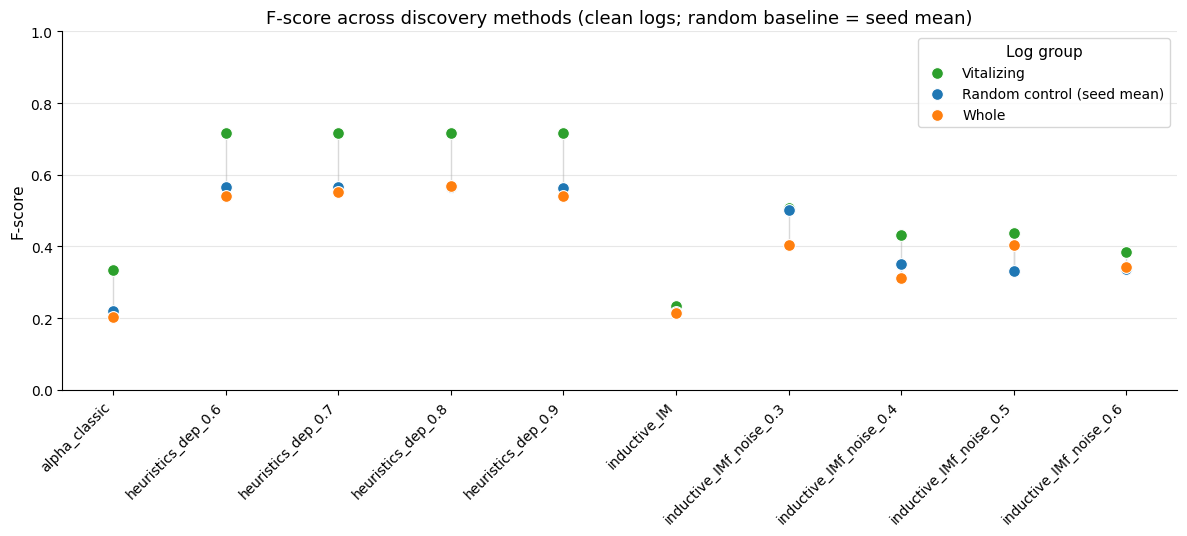

In [20]:
# -----------------------------------------
# Publication F-score slopegraph (repro consolidated table)
# -----------------------------------------
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

LOG_LABELS = {
    "vitalizing": "Vitalizing",
    "random_case_control": "Random control (seed mean)",
    "whole": "Whole",
}

plot_df_repro = consolidated_results_table_clean_repro[
    consolidated_results_table_clean_repro["status"] == "ok"
].copy()
wide_f_score_repro = (
    plot_df_repro.pivot(index="log_name", columns="discovery_method", values="f_score")
    .reindex(LOG_ORDER)
    .sort_index(axis=1)
)

slope_data = wide_f_score_repro.reindex(LOG_ORDER)
configs = list(slope_data.columns)
x = np.arange(len(configs))

fig, ax = plt.subplots(figsize=(12, 5.5))
for cfg_idx in range(len(configs)):
    y_vals = slope_data.iloc[:, cfg_idx].astype(float).values
    ax.plot(
        [cfg_idx] * len(LOG_ORDER),
        y_vals,
        color="#d9d9d9",
        linewidth=1.0,
        zorder=1,
    )
    for log_name in LOG_ORDER:
        if log_name not in slope_data.index:
            continue
        ax.scatter(
            cfg_idx,
            slope_data.loc[log_name, configs[cfg_idx]],
            color=LOG_COLORS.get(log_name),
            s=72,
            zorder=2,
            edgecolors="white",
            linewidths=0.8,
            label=LOG_LABELS.get(log_name) if cfg_idx == 0 else None,
        )

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha="right")
ax.set_ylabel("F-score")
ax.set_title("F-score across discovery methods (clean logs; random baseline = seed mean)")
ax.legend(title="Log group", frameon=True)
_style_axes(ax, ylim01=True)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "clean_log_f_score_slopegraph_repro.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "clean_log_f_score_slopegraph_repro.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIGURES_DIR / 'clean_log_f_score_slopegraph_repro'}.{{png,pdf}}")
plt.show()